# KHỞI TẠO MÔI TRƯỜNG VÀ DATABASE ẢO

In [6]:
import os       # quan li path, lam viec voi bien moi truong  env
import uuid     # tao ID, dung trong tracking request, session chat, id document,...
import operator # cung cap cac phep toan dang function (add, multi, ) dung cho merge
import logging

"""
Typing nang cao:
    Annotated: gắn meradata vào type
    TypedDict: ddinhhj nghĩa schema của state
    Lieral: giới han giá trị 
"""
from typing import Annotated, Literal, TypedDict

# load API từ .env
from dotenv import load_dotenv

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

# load API key
load_dotenv()

# giả lập database TRẠM CỨU HỘ
RESCUE_DB = {
    "hà nội":[
        {"name":"Cứu hộ 24/7 Hà Nội", "phone":"0923-xxx-xxx", "Services":["kích bình","cẩu xe"]},
        {"name":"Gara Phú Phong", "phone":"0956-xxx-xxx", "Services":["vá lốp","thay lốp"]}
    ],
    "đà nẵng":[
        {"name":"Cứu hộ Đà Thành", "phone":"0943-xxx-xxx", "Services":["thay lốp","sửa máy"]},
        {"name":"Team Phong 43", "phone":"0911-xxx-xxx", "Services":["bơm xăng","cẩu xe"]}
    ],
    "hồ chí minh":
        {"name":"đội cứu hộ quận 1", "phone":"0905-xxx-xxx", "Services":["bơm xăng","cẩu xe"]},
}

print("khởi tạo thhanfh công thư viện và DB giả lập")

khởi tạo thhanfh công thư viện và DB giả lập


# ĐỊNH NGHĨA KHOI TẠO TOOL TRA CỨU (SEARCH TOOL) CHO AGENT

In [7]:
@tool
# ↑ Decorator: biến function này thành "tool" để LLM (LangChain/LangGraph) có thể gọi

def search_rescue_station(city: str) -> str:
    """
    Tìm kiếm và cung cấp danh sách các trạm cứu hộ giao thông.
    
    KHI NÀO NÊN DÙNG (When to use):
    - Khi người dùng thông báo xe bị hỏng, gặp tai nạn hoặc cần cứu hộ.
    - Khi người dùng hỏi về địa chỉ hoặc số điện thoại đội cứu hộ giao thông tại một khu vực/thành phố cụ thể.
    
    ĐẦU VÀO (Inputs):
    - city (str): Tên thành phố hoặc tỉnh thành nơi cần tìm kiếm cứu hộ (ví dụ: "Hà Nội", "Hồ Chí Minh", "Đà Nẵng"). Không sử dụng từ viết tắt.
    
    ĐẦU RA (Outputs):
    - Trả về danh sách chuỗi văn bản chứa tên, địa chỉ và hotline của các trạm cứu hộ trong thành phố đó. Nếu không tìm thấy sẽ trả về thông báo lỗi.
    """
    
    city_lower = city.lower().strip()
    # city: input từ user (ví dụ: " Da Nang ")
    # .lower(): chuyển thành chữ thường → "da nang"
    # .strip(): xoá khoảng trắng đầu/cuối
    # => giúp match key trong database chính xác hơn

    print(f"\n [Node Tool] dang tim tram cuu ho tai: {city}")
    # Log debug:
    # - \n: xuống dòng cho dễ đọc log
    # - f-string: chèn biến city vào chuỗi
    # - dùng để biết khi nào tool được gọi trong hệ thống

    if city_lower in RESCUE_DB:
    # Kiểm tra:
    # - RESCUE_DB là dictionary (database giả lập)
    # - key là tên thành phố (đã normalize)
    # - nếu tồn tại → xử lý tiếp

        station = RESCUE_DB[city_lower]
        # Lấy danh sách các trạm cứu hộ của thành phố
        # station là LIST các dictionary

        res = f"tim thay {len(station)} tram tai {city}: \n"
        # len(station): số lượng trạm
        # {city}: giữ nguyên input user (không dùng city_lower để hiển thị đẹp hơn)
        # res: biến string để build kết quả trả về

        for s in station:
        # Duyệt từng trạm trong danh sách
        # s là 1 dictionary, ví dụ:
        # {
        #   "name": "Rescue A",
        #   "phone": "0123",
        #   "services": ["keo xe", "sua xe"]
        # }

            res += f"- {s['name']} (SDT: {s['phone']}: Ho tro {', '.join(s['Services'])})\n"
            # res += : nối thêm vào chuỗi kết quả
            
            # s['name']: lấy tên trạm
            # s['phone']: lấy số điện thoại
            # s['services']: list dịch vụ
            
            # ', '.join(...):
            # - biến list → string
            # ["keo xe", "sua xe"] → "keo xe, sua xe"
            
            # \n: xuống dòng cho mỗi trạm

        return res
        # Trả về toàn bộ chuỗi kết quả cho LLM

    else:
        return f"rat tiec, kong co duw lieu ve doi cuu ho cua thanh pho '{city}' nay"
        # Trường hợp không tìm thấy:
        # - trả về thông báo lỗi thân thiện
        # - vẫn dùng city gốc để hiển thị đẹp

# =========================

tools = [search_rescue_station]
# Tạo danh sách tool
# LangGraph / Agent sẽ nhận list này để biết có những tool nào có thể dùng

print("tool 'search_rescue_station' da san dang")
# Log: báo tool đã được load xong (debug / kiểm tra hệ thống)

tool 'search_rescue_station' da san dang


# CẤU HÌNH BỘ NÃO CỦA LLM VÀ DỌC LOGIC ĐỒ THỊ (LANGGRAPH)

In [8]:
from langchain_core.messages import SystemMessage
# khoi tao model
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

llm_with_tool = llm.bind_tools(tools)


# khai bao trang thai (tran thai hoi thoai)
class MessagesState(TypedDict):
    messages: Annotated[list, operator.add]
    
# dinh nghia node suy nghi (model node)
def agent_node(state: MessagesState):
    system_prompt = SystemMessage(
        content=(
        "Bạn là chuyên gia điều phối cứu hộ giao thông chuyên nghiệp. "
        "Hãy hỏi tên xe và vị trí của khách hàng. "
        "Hãy dùng tool 'search_rescue_stations' khi biết khách đang ở thành phố nào để tìm trạm gần đó. "
        "Luôn lịch sự và trấn an khách hàng."
        )
    )
    
    messages = [system_prompt] + state["messages"]
    response = llm_with_tool.invoke(messages)
    
    return {"messages": [response]}

# dinh nghia edge re nhanh (router)
def should_continue(state: MessagesState) -> Literal["tools","__end__"]:
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    return END


# xay dung do thi 
builder = StateGraph(MessagesState)
builder.add_node("agent", agent_node)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", should_continue)
builder.add_edge("tools","agent")

# tich hop bo nho
memory = MemorySaver()
app = builder.compile(checkpointer=memory)

print("Agent Graph da duoc bien dich thanh cong")

Agent Graph da duoc bien dich thanh cong


Đang vẽ đồ thị Agent...


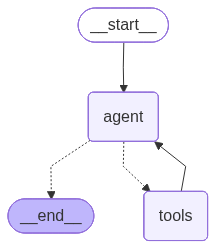

In [9]:
from IPython.display import Image, display

# Cách 1: Vẽ và hiển thị trực tiếp bằng hình ảnh PNG (Khuyên dùng)
try:
    print("Đang vẽ đồ thị Agent...")
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Không thể vẽ ảnh PNG (có thể thiếu thư viện). Chuyển sang in mã Mermaid.")
    
    # Cách 2: In ra đoạn mã văn bản định dạng Mermaid
    # (Bạn có thể copy mã này dán vào https://mermaid.live/ để xem ảnh)
    print("\n=== MÃ MERMAID ===")
    print(app.get_graph().draw_mermaid())


# CHAY AGENT VOI TRI NHO STREAMING

In [11]:
def chat_with_rescue_agent(user_input, thread_id):
    print(f"\n User: {user_input}")
    print("Agent : ", end="")

    inputs = {"messages": [("user", user_input)]}
    config = {"configurable": {"thread_id": thread_id}}
    
    # 1. BẮT BUỘC thêm stream_mode="messages" ở dòng này
    stream = app.stream(inputs, config=config, stream_mode="messages")
    
    for chunk, metadata in stream:
        # 2. Sửa lại chữ "agnet" thành "agent" cho đúng
        if metadata.get("langgraph_node") == "agent" and chunk.content:
            print(chunk.content, end="", flush=True)
            
    print("\n" + "-"*20)

# tao mot phien chat moi
my_session = str(uuid.uuid4())


# Lần 1: Chào hỏi
chat_with_rescue_agent("Chào bạn, tôi đang gặp sự cố xe hỏng!", my_session)
# Lần 2: Cung cấp vị trí (Agent sẽ tự gọi Tool)
chat_with_rescue_agent("Tôi đang ở TP Đà Nẵng, xe tôi bị hết xăng.", my_session)
# Lần 3: Kiểm tra trí nhớ (Không nhắc lại địa điểm)
chat_with_rescue_agent("À, vậy nếu tôi muốn kéo xe thì gọi trạm nào?", my_session)


 User: Chào bạn, tôi đang gặp sự cố xe hỏng!
Agent : Chào bạn, tôi rất tiếc khi biết bạn đang gặp sự cố. Đừng lo lắng, chúng tôi sẽ giúp bạn.

Để tôi có thể hỗ trợ bạn tốt nhất, bạn vui lòng cho tôi biết:

1.  **Tên xe của bạn là gì?** (Ví dụ: Honda Civic, Toyota Camry, Ford Ranger, v.v.)
2.  **Bạn đang ở vị trí nào?** (Vui lòng cung cấp tên đường, quận/huyện và thành phố bạn đang ở.)

Sau khi có thông tin này, tôi sẽ tìm trạm cứu hộ gần nhất cho bạn.
--------------------

 User: Tôi đang ở TP Đà Nẵng, xe tôi bị hết xăng.
Agent : [{'type': 'text', 'text': 'Cảm ơn bạn đã cung cấp thông tin. Tôi đã nắm được bạn đang ở TP Đà Nẵng và xe của bạn bị hết xăng. Đừng lo lắng,', 'extras': {'signature': 'CiQBvj72+16skLCcAJ54vKr5k3gvTPNvB5oB5ZqXl0jToFK8TjAKZAG+Pvb7s4Oy0jQWgdYMH1Qv+O1Z6pjHNjcNc+IW26iqktfour53lFxMSwECS/2V2rYaVdwyERvo8I8RiF4PYjhMho3/SEY2mUQPIYj47tiurt89t3cC3lEsJDCv5fWBFDiJSh4K5QEBvj72+38Qfejk1L4UbIi7QlrPScFfjBuOJb21U2mFBFIQHhXfl2kXAYMqCJE65X0FbGCmql8IvSmZ1USKTvjHKVc3zSmcgp7vD7Xh0y8h